# RQ2 analysis template: from profiling traces to CBS budgets

Copy this notebook next to a new workload's `results/` folder, edit **only the configuration cell** (section 0) and run all cells from top to bottom.
Every cell produces one table or one figure. The procedure:

| # | Step | Result |
|---|---|---|
| 1 | Stress profiling | C and W statistics per condition |
| 2 | Tail estimation | block maxima, GEV fit, platform-event check, bounds C_p |
| 3 | α_drift | spread of the baseline bounds over runs and VMs of the same type |
| 4 | α_cores | stressed / baseline bound on a second VM, rule for m |
| 5 | Budgets | Route 1, Route 2, Route 3, admission, risk curves, check on the second VM |
| 6 | p_floor | stalls and late jobs that no budget removes |
| 7 | Offline replay | held-out baselines, burst check on stressed traces |
| 8 | Online validation | KubeDeadline runs: P(C ≤ B*), over-budget, deadline misses |

**Data layout expected** (one CSV per instance, columns `instance_id, job_id, frame_idx, release_ns, start_ns, end_ns, cpu_ns, response_ns, wait_ns, lateness_ns, deadline_met, skipped, warmup`, plus `<instance>.meta.json`):

- `results/<scenario>/<condition>/<instance>.csv`: profiling session (baselines and stress conditions)
- `alpha_drift/results/<vm>/<scenario>/baseline/` and `.../<STRESS_COND>/`: runs on other VMs
- `validation/results/<scenario>/<route>/<p tag>_<interference>/`: online validation (only for section 8) (folders on disk: `route1`, `route2b` = Route 2, `hwm` = Route 3)

**Notation.** C = CPU time of a job (`cpu_ns`), W = dispatch latency (`start_ns − release_ns`), T = period = deadline, Q = budget, p = tolerance, the admissible probability that a job's execution time exceeds its budget: P(C > Q) ≤ p, C_p = (1−p) quantile bound of C.

## 0. Configuration and helpers

In [1]:
from pathlib import Path
import json, math, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genextreme, gumbel_r, chi2, binom, beta

pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.float_format", "{:.3f}".format)

# ======================== EDIT HERE FOR A NEW WORKLOAD ========================
RQ2 = Path("../workload3")                                                       # folder that holds results/, alpha_drift/, validation/
SCENARIOS  = {"single_core": ["instance0"], "multi_core": ["instance0", "instance1"]}   # scenario -> instances
CONDITIONS = ["baseline1", "cache", "memory", "baseline2"]             # profiling conditions
BASELINES, STRESS = ["baseline1", "baseline2"], ["cache", "memory"]
P_LIST, TEST_P = [1e-1, 1e-2, 1e-3], [1e-2, 1e-3]                      # tolerances; TEST_P = the ones used in the pass tests

S1_VM      = {"single_core": "worker6", "multi_core": "worker7"}       # VM of the profiling session, per scenario
TEST_VM    = {"single_core": "worker7", "multi_core": "worker6"}       # second VM (same type), per scenario
DRIFT_VMS  = ["worker6", "worker7"]                                    # VMs that have a baseline in alpha_drift/results/<vm>/<scenario>/baseline
EXCLUDE_VMS = ("worker0",)                                             # other VM type (SMT): kept out of every drift pool
STRESS_COND = "memory"                                                 # stressor used on the test VM

ALPHA_PLATFORM = {1: 1.03, 2: 1.06, 3: 1.11}                           # alpha_cores,platform(m), m = number of enemy cores
M_USED = {"single_core": 3, "multi_core": 2}                           # decision per scenario (see section 4)
ADMISSION_MAX = 0.95                                                   # driver admission threshold Q/T
HWM_STRESS, HWM_P = ("cache", "memory"), 1e-3                         # Route 3: runs whose maximum is taken, p of alpha_drift
K_LIST = [10, 100]                                                     # window lengths of the worst-case (m,k)

BLOCK, P_GEV, RUNS_R = 1000, 1e-3, 50         # block size (jobs) for block maxima, GEV only at p <= P_GEV, runs-method gap for clusters
L_BOOT, N_BOOT, ALPHA = 1000, 300, 0.05       # moving-block bootstrap: block length, replicates, one-sided 95% upper bound
THR_MS = 1.0                                  # residual above this (ms) = candidate platform event
W_THRESH_MS = 5                               # a dispatch latency above this counts as "large"
JOBS_VALIDATION = 50000                       # jobs per online validation run
VAL_ROUTES = ("route1", "route2", "route3")           # online validation routes (route3: one budget, one run for every p)
VAL_DIRS = {"route1": "route1", "route2": "route2b", "route3": "hwm"}   # route -> its folder in validation/results (folders keep the old names)
VAL_P = {"p1e-1": 0.1, "p1e-2": 0.01, "p1e-3": 0.001}
# ==============================================================================

S1, S2, VAL = RQ2 / "results", RQ2 / "alpha_drift" / "results", RQ2 / "validation" / "results"
_meta = json.load(open(S1 / next(iter(SCENARIOS)) / CONDITIONS[0] / "instance0.meta.json"))
T_MS = float(_meta["args"]["period_ms"])                              # period = deadline, read from the run
print(f"period T = {T_MS} ms; scenarios: { {s: len(i) for s, i in SCENARIOS.items()} } instance(s)")

period T = 10.0 ms; scenarios: {'single_core': 1, 'multi_core': 2} instance(s)


In [2]:
rng = np.random.default_rng(0)

def load_series(path):
    """CPU time C (ms) of the executed jobs of one run, in job order (warm-up and skipped jobs dropped)"""
    df = pd.read_csv(path, usecols=["job_id", "skipped", "warmup", "cpu_ns"])
    df = df[(df.skipped == 0) & (df.warmup == 0)].sort_values("job_id")
    return (df.cpu_ns / 1e6).to_numpy()

def block_maxima(x, b=BLOCK):
    k = len(x) // b
    return x[: k * b].reshape(k, b).max(axis=1)

def boot_dist(x, ps=P_LIST, L=L_BOOT, B=N_BOOT):
    """moving-block bootstrap distribution of the (1-p) quantiles, shape (B, len(ps))"""
    qs, n = 1 - np.asarray(ps), len(x)
    k, ar = n // L, np.arange(L)
    out = np.empty((B, len(ps)))
    for i in range(B):
        starts = rng.integers(0, n - L + 1, size=k)
        out[i] = np.quantile(x[(starts[:, None] + ar).ravel()], qs)
    return out

def empirical_bound(x, ps, L=L_BOOT):
    """point (1-p) quantile and its upper 95% bound (moving-block bootstrap, keeps temporal dependence)"""
    return np.quantile(x, 1 - np.asarray(ps)), np.quantile(boot_dist(x, ps, L), 1 - ALPHA, axis=0)

def extremal_index(x, p, r=RUNS_R):
    """runs estimator: clusters of exceedances of the (1-p) quantile / exceedances"""
    idx = np.flatnonzero(x > np.quantile(x, 1 - p))
    return (1 + np.sum(np.diff(idx) > r)) / len(idx) if len(idx) else np.nan

def gev_theta(x, p, b, theta):
    """GEV bound of the per-job (1-p) level from block maxima, with extremal index; shape xi; LR test Gumbel vs GEV"""
    mx = block_maxima(x, b)
    c, loc, scale = genextreme.fit(mx)
    bound = genextreme.ppf((1 - p) ** (b * theta), c, loc, scale)
    lg, sg = gumbel_r.fit(mx)
    lr = 2 * (genextreme.logpdf(mx, c, loc, scale).sum() - gumbel_r.logpdf(mx, lg, sg).sum())
    return bound, -c, chi2.sf(lr, 1)

def exceed_test(x, C, p, r=RUNS_R):
    """cluster-aware test that C is a valid (1-p) bound: (exceedances, clusters, expected clusters, p-value)"""
    pos = np.flatnonzero(x > C)
    kc = (1 + int(np.sum(np.diff(pos) > r))) if len(pos) else 0
    n_eff = max(int(round(len(x) * extremal_index(x, p, r))), 1)
    return len(pos), kc, n_eff * p, (binom.sf(kc - 1, n_eff, p) if kc else 1.0)

def cp_upper(k, n, conf=0.95):
    """one-sided Clopper-Pearson upper bound for k events in n trials"""
    if n == 0:
        return np.nan
    return 1 - (1 - conf) ** (1 / n) if k == 0 else beta.ppf(conf, k + 1, n - k)

def overlap_mask(sa, ea, sb, eb):
    """for each interval [sa, ea]: does any interval [sb, eb] overlap it?"""
    out = np.zeros(len(sa), dtype=bool)
    if len(sa) == 0 or len(sb) == 0:
        return out
    o = np.argsort(sb)
    sb, eb = sb[o], eb[o]
    pm = np.maximum.accumulate(eb)                      # latest end among the intervals that start first
    hi = np.searchsorted(sb, ea, side="right")          # intervals of B that start before A ends
    ok = hi > 0
    out[ok] = pm[hi[ok] - 1] >= sa[ok]
    return out

def mk_worst(over, k):
    """minimum number of jobs within the budget (C <= Q) in any window of k consecutive jobs"""
    if len(over) < k:
        return np.nan
    return int(np.convolve((~over).astype(np.int64), np.ones(k, dtype=np.int64), mode="valid").min())

def max_consecutive(over):
    if not over.any():
        return 0
    e = np.diff(np.concatenate(([0], over.astype(np.int8), [0])))
    return int((np.flatnonzero(e == -1) - np.flatnonzero(e == 1)).max())

def replay(x, q, p):
    """budget overruns C > Q on a trace"""
    over = x > q
    out = dict(overrun_rate=over.mean(), overrun_over_p=over.mean() / p, max_consec=max_consecutive(over))
    for k in K_LIST:
        out[f"mk_worst_k{k}"] = mk_worst(over, k)
    return out

## 1. Stress profiling

The workload runs without stress, under the cache enemy, under the memory enemy, and once more without stress.
Skipped activations have no timestamps and are not in the statistics (their count is in the table).
**Reading the table:** the last two rows are the stress effect in % against the mean of the baselines. A large effect at `max` and a small one at `p50` means the stress only touches the tail.

In [3]:
frames = []
for scen, insts in SCENARIOS.items():
    for cond in CONDITIONS:
        for inst in insts:
            df = pd.read_csv(S1 / scen / cond / f"{inst}.csv")
            df["scenario"], df["condition"] = scen, cond
            frames.append(df)
raw = pd.concat(frames, ignore_index=True)
skipped = raw.groupby(["scenario", "condition"], sort=False).skipped.sum()

data = raw[(raw.skipped == 0) & (raw.warmup == 0)].copy()
data["C_ms"] = data.cpu_ns / 1e6
data["W_us"] = (data.start_ns - data.release_ns) / 1e3
data = data.sort_values(["scenario", "condition", "instance_id", "job_id"]).reset_index(drop=True)
s1_series = {k: g.C_ms.to_numpy() for k, g in data.groupby(["scenario", "condition", "instance_id"])}   # C per profiling run

STAT = {"p50": .5, "p99": .99, "p99.9": .999, "max": 1.0}
for scen in SCENARIOS:
    d = data[data.scenario == scen]
    t = d.groupby("condition").C_ms.quantile(list(STAT.values())).unstack().set_axis([f"C {k} (ms)" for k in STAT], axis=1)
    t["W p50 (µs)"] = d.groupby("condition").W_us.median()
    t["W max (ms)"] = d.groupby("condition").W_us.max() / 1e3
    t[f"W > {W_THRESH_MS} ms"] = d.groupby("condition").W_us.agg(lambda w: int((w > W_THRESH_MS * 1e3).sum()))
    t["skipped"] = skipped[scen]
    t = t.loc[CONDITIONS]
    cols = [c for c in t.columns if c.startswith("C ")]
    for s in STRESS:
        t.loc[f"{s} vs baselines (%)", cols] = (t.loc[s, cols] / t.loc[BASELINES, cols].mean() - 1) * 100
    print(f"--- {scen} (instances pooled) ---")
    display(t.round(2).fillna(""))

--- single_core (instances pooled) ---


,C p50 (ms),C p99 (ms),C p99.9 (ms),C max (ms),W p50 (µs),W max (ms),W > 5 ms,skipped
condition,,,,,,,,
baseline1,0.960,1.050,1.200,5.950,21.080,2.990,0.000,0.000
cache,0.970,1.060,1.220,6.680,21.440,25.610,2.000,3.000
memory,0.960,1.040,1.150,3.920,20.380,16.270,2.000,1.000
baseline2,0.960,1.060,1.160,5.630,19.780,22.760,3.000,4.000
cache vs baselines (%),0.650,0.910,3.090,15.390,,,,
memory vs baselines (%),-0.580,-1.750,-2.510,-32.380,,,,


--- multi_core (instances pooled) ---


,C p50 (ms),C p99 (ms),C p99.9 (ms),C max (ms),W p50 (µs),W max (ms),W > 5 ms,skipped
condition,,,,,,,,
baseline1,0.940,1.070,1.220,3.150,25.200,37.570,38.000,14.000
cache,0.920,1.080,1.140,2.500,24.740,11.410,26.000,2.000
memory,0.940,1.050,1.120,2.070,26.200,14.380,36.000,34.000
baseline2,0.940,1.070,1.160,2.570,26.440,41.480,36.000,32.000
cache vs baselines (%),-2.200,0.700,-4.480,-12.730,,,,
memory vs baselines (%),-0.690,-2.100,-6.130,-27.470,,,,


## 2. Tail estimation

### 2.1 Block maxima and GEV fit
The trace is cut into blocks of `BLOCK` jobs, the maximum of each block is fitted with a GEV (shape ξ; scipy's `c = −ξ`), instances pooled.
**Reading the table:** ξ < 0 is a bounded tail and `upper end` is the fitted upper end point; ξ ≥ 0 has no upper end. `max block` is the largest observed block maximum.

In [4]:
bm = {(s, c): np.concatenate([block_maxima(s1_series[(s, c, i)]) for i in SCENARIOS[s]]) for s in SCENARIOS for c in CONDITIONS}
rows = []
for (s, c), x in bm.items():
    cc, loc, scale = genextreme.fit(x)
    rows.append(dict(scenario=s, condition=c, n_blocks=len(x), xi=-cc, loc=loc, scale=scale,
                     **{"upper end": loc + scale / cc if cc > 0 else np.nan}, **{"max block": x.max()}))
fits = pd.DataFrame(rows).set_index(["scenario", "condition"])
display(fits.round(3))

n_blocks    xi   loc  scale  upper end  max block
scenario    condition                                                   
single_core baseline1       100 0.941 1.130  0.105        NaN      5.950
            cache            99 0.764 1.207  0.158        NaN      6.684
            memory           99 0.747 1.133  0.128        NaN      3.917
            baseline2        99 0.985 1.135  0.090        NaN      5.635
multi_core  baseline1       198 0.571 1.115  0.063        NaN      3.151
            cache           198 0.312 1.129  0.051        NaN      2.495
            memory          198 0.234 1.092  0.069        NaN      2.074
            baseline2       198 0.284 1.126  0.079        NaN      2.569

### 2.2 Fit diagnostics
One figure per scenario, one column per condition: histogram of the block maxima with the fitted pdf, QQ plot (points on the dashed line = good fit), return level plot.

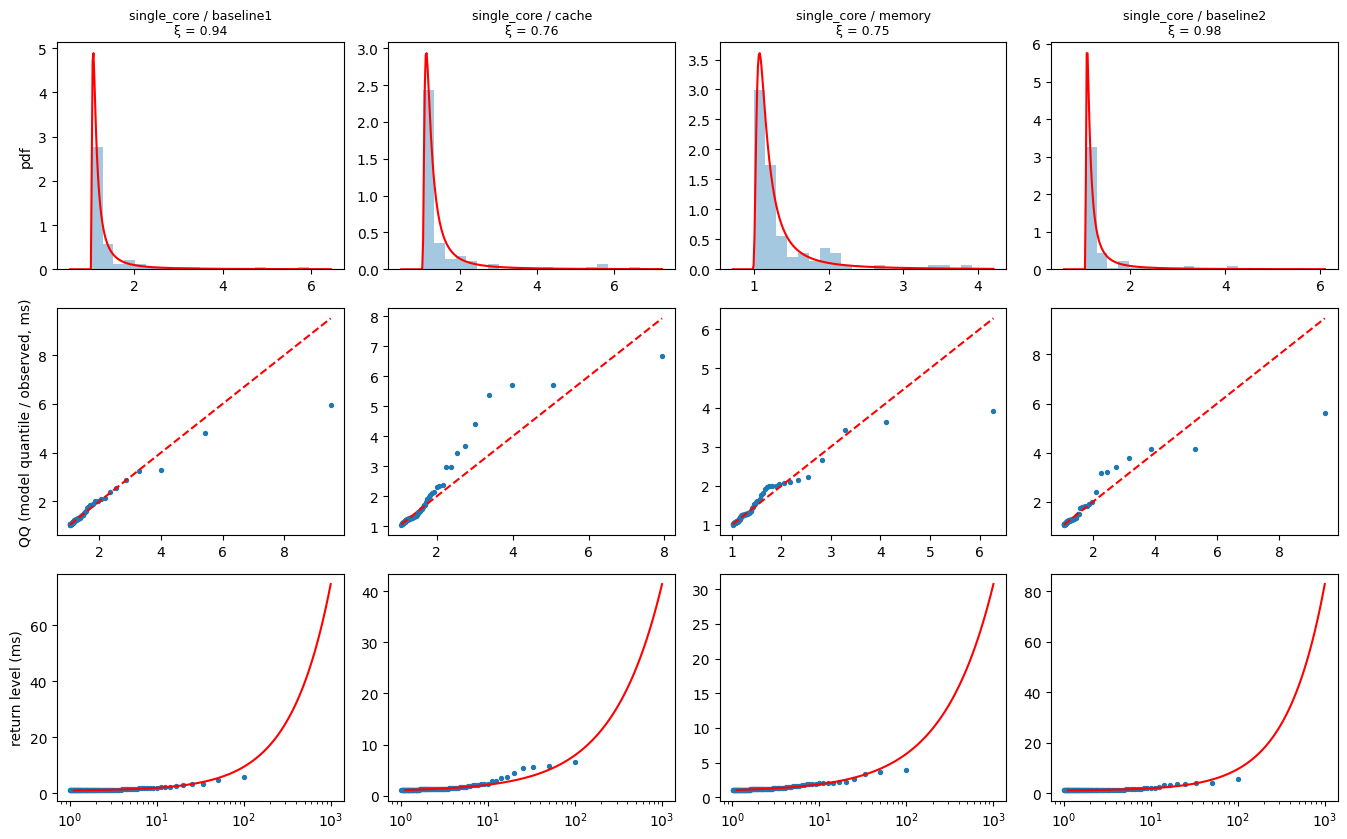

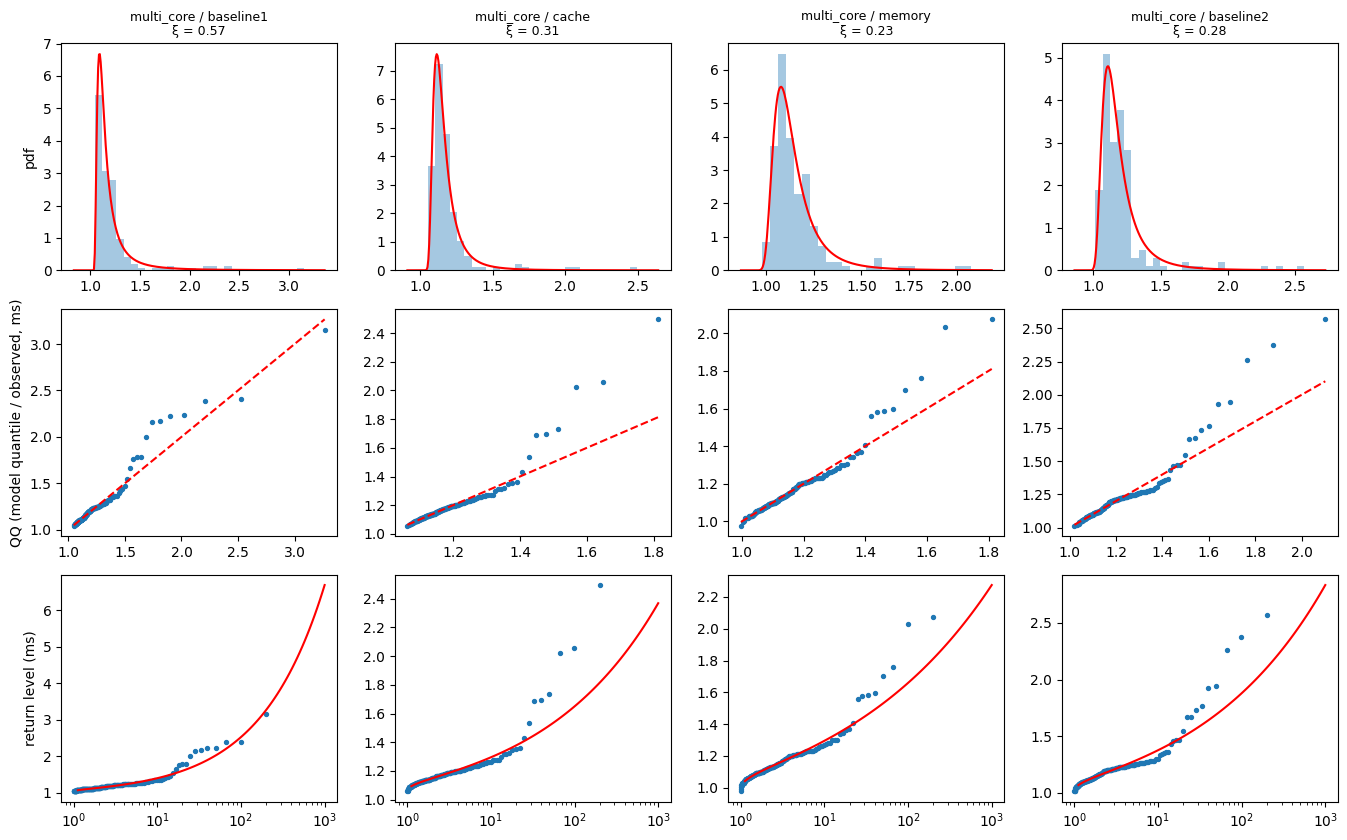

In [5]:
for s in SCENARIOS:
    fig, ax = plt.subplots(3, len(CONDITIONS), figsize=(3.4 * len(CONDITIONS), 8.5), squeeze=False)
    for j, c in enumerate(CONDITIONS):
        x = bm[(s, c)]
        cc, loc, scale = genextreme.fit(x)
        xs = np.sort(x); pr = np.arange(1, len(xs) + 1) / (len(xs) + 1)
        grid = np.linspace(xs.min() - 0.1 * np.ptp(xs), xs.max() + 0.1 * np.ptp(xs), 300)
        ax[0, j].hist(x, bins="auto", density=True, alpha=.4); ax[0, j].plot(grid, genextreme.pdf(grid, cc, loc, scale), "r-")
        ax[0, j].set_title(f"{s} / {c}\nξ = {-cc:.2f}", fontsize=9)
        q = genextreme.ppf(pr, cc, loc, scale)
        ax[1, j].scatter(q, xs, s=8); ax[1, j].plot([q.min(), q.max()], [q.min(), q.max()], "r--")
        T = np.logspace(0.05, 3, 100)
        ax[2, j].semilogx(T, genextreme.isf(1 / T, cc, loc, scale), "r-"); ax[2, j].scatter(1 / (1 - pr), xs, s=8)
    for r, lab in enumerate(["pdf", "QQ (model quantile / observed, ms)", "return level (ms)"]):
        ax[r, 0].set_ylabel(lab)
    plt.tight_layout(); plt.show()

### 2.3 Platform-event check (scenarios with two or more instances)
Both instances run the same clip in lockstep, so a job that is slow on both at the same time points to the platform and not to the task.
For each job the **residual** is its C minus the median C of the same frame (the content effect is removed). A job with a residual above `THR_MS` is a candidate; a candidate that overlaps a candidate of the other instance is a **coincident event**.
`expected by chance` comes from shifting one instance's candidates by random offsets (200 replicates); a small `p-value` means the coincidences are real.

In [6]:
PAIR = [s for s in SCENARIOS if len(SCENARIOS[s]) >= 2]
N_SHIFT = 200
d = data.copy()
d["resid_ms"] = d.C_ms - d.groupby(["scenario", "condition", "instance_id", "frame_idx"]).C_ms.transform("median")
d["platform_event"] = False
rows = []
for s in PAIR:
    ia, ib = SCENARIOS[s][:2]
    for c in CONDITIONS:
        g = d[(d.scenario == s) & (d.condition == c)]
        a = g[(g.instance_id == ia) & (g.resid_ms > THR_MS)]
        b = g[(g.instance_id == ib) & (g.resid_ms > THR_MS)]
        sa, ea, sb, eb = a.start_ns.to_numpy(), a.end_ns.to_numpy(), b.start_ns.to_numpy(), b.end_ns.to_numpy()
        ma, mb = overlap_mask(sa, ea, sb, eb), overlap_mask(sb, eb, sa, ea)
        d.loc[a.index[ma], "platform_event"] = True
        d.loc[b.index[mb], "platform_event"] = True
        t0, span = g.start_ns.min(), g.end_ns.max() - g.start_ns.min()
        null = [overlap_mask(sa, ea, (sb - t0 + o) % span + t0, (sb - t0 + o) % span + t0 + (eb - sb)).sum()
                for o in rng.integers(0, span, N_SHIFT)]
        rows.append(dict(scenario=s, condition=c, **{f"candidates {ia}": len(a), f"candidates {ib}": len(b)},
                         coincident=int(ma.sum()), **{"expected by chance": np.mean(null)},
                         **{"p-value": (1 + np.sum(np.array(null) >= ma.sum())) / (1 + N_SHIFT)},
                         **{"events per 1000 jobs": 1000 * ma.sum() / len(g[g.instance_id == ia])}))
events = pd.DataFrame(rows).set_index(["scenario", "condition"]) if rows else None
display(events.round(3) if events is not None else "no scenario with two instances")

candidates instance0  candidates instance1  coincident  expected by chance  p-value  events per 1000 jobs
scenario   condition                                                                                                           
multi_core baseline1                     0                     0           0               0.000    1.000                 0.000
           cache                         0                     0           0               0.000    1.000                 0.000
           memory                        0                     0           0               0.000    1.000                 0.000
           baseline2                     0                     0           0               0.000    1.000                 0.000

### 2.4 GEV with and without the coincident events
Same fit as 2.1, per instance, once with all jobs and once without the jobs marked as coincident events.
**Reading the table:** if ξ moves from positive to negative and the upper end drops when the events are removed, the heavy tail comes from the platform events and not from the task. The events stay in the budget (conservative); this table only explains the tail.

In [7]:
rows = []
for s in PAIR:
    for c in CONDITIONS:
        for i in SCENARIOS[s]:
            g = d[(d.scenario == s) & (d.condition == c) & (d.instance_id == i)]
            res = {}
            for label, x in (("with", g.C_ms.to_numpy()), ("without", g.C_ms[~g.platform_event].to_numpy())):
                cc, loc, scale = genextreme.fit(block_maxima(x))
                res[label] = (-cc, loc + scale / cc if cc > 0 else np.nan)
            rows.append(dict(scenario=s, condition=c, instance_id=i, removed=int(g.platform_event.sum()),
                             xi_with=res["with"][0], xi_without=res["without"][0],
                             upper_end_with=res["with"][1], upper_end_without=res["without"][1]))
display(pd.DataFrame(rows).set_index(["scenario", "condition", "instance_id"]).round(3) if rows else "no scenario with two instances")

removed  xi_with  xi_without  upper_end_with  upper_end_without
scenario   condition instance_id                                                                 
multi_core baseline1 instance0          0    0.568       0.568             NaN                NaN
                     instance1          0    0.642       0.642             NaN                NaN
           cache     instance0          0    0.357       0.357             NaN                NaN
                     instance1          0    0.249       0.249             NaN                NaN
           memory    instance0          0    0.224       0.224             NaN                NaN
                     instance1          0    0.352       0.352             NaN                NaN
           baseline2 instance0          0    0.305       0.305             NaN                NaN
                     instance1          0    0.259       0.259             NaN                NaN

### 2.5 Bounds C_p
C_p is the (1−p) quantile of C with an upper 95% confidence bound from a moving-block bootstrap (`L_BOOT` jobs per block, so temporal dependence is kept).
The GEV bound (with the extremal index θ, runs method) is used only at p ≤ `P_GEV`, where it can be compared with the empirical bound. The last column repeats the bound at `P_GEV` with a block twice as long.
**Reading the table:** `C_<p>` columns are the empirical upper bounds; `GEV` should be close to (slightly below) the empirical bound at `P_GEV`; θ < 1 means the extremes cluster a little; a large LRT p-value means a Gumbel tail (ξ = 0) is not rejected.

In [8]:
rows, wide = [], []
for (s, c, i), x in s1_series.items():
    point, ucb = empirical_bound(x, P_LIST)
    th = extremal_index(x, P_GEV)
    gev, xi, p_lrt = gev_theta(x, P_GEV, BLOCK, th)
    ucb2 = empirical_bound(x, [P_GEV], L=2 * L_BOOT)[1][0]
    for k, p in enumerate(P_LIST):
        rows.append(dict(scenario=s, condition=c, instance_id=i, p=p, emp=point[k], ucb=ucb[k], gev=gev if p == P_GEV else np.nan))
    wide.append(dict(scenario=s, condition=c, instance_id=i, **{f"C_{p:g}": ucb[k] for k, p in enumerate(P_LIST)},
                     GEV=gev, theta=th, xi=xi, LRT_p=p_lrt, **{f"C_{P_GEV:g} (2L)": ucb2}))
bounds = pd.DataFrame(rows)
display(pd.DataFrame(wide).set_index(["scenario", "instance_id", "condition"]).sort_index().round(3))

C_0.1  C_0.01  C_0.001   GEV  theta    xi  LRT_p  C_0.001 (2L)
scenario    instance_id condition                                                                
multi_core  instance0   baseline1  1.001   1.069    1.652 1.214  0.290 0.568  0.000         1.652
                        baseline2  0.998   1.074    1.197 1.173  0.580 0.305  0.000         1.210
                        cache      1.009   1.080    1.153 1.143  0.840 0.357  0.000         1.153
                        memory     0.976   1.044    1.131 1.109  0.710 0.224  0.000         1.129
            instance1   baseline1  1.011   1.089    1.665 1.245  0.280 0.642  0.000         1.665
                        baseline2  0.998   1.066    1.219 1.167  0.620 0.259  0.000         1.218
                        cache      1.016   1.079    1.140 1.136  0.800 0.249  0.000         1.140
                        memory     0.993   1.057    1.134 1.121  0.680 0.352  0.000         1.134
single_core instance0   baseline1  0.991   1.051    1.237 1.163  0.760 0.941  0.000         1.237
                        baseline2  1.018   1.063    1.180 1.152  0.840 0.985  0.000         1.179
                        cache      1.004   1.068    1.237 1.234  0.850 0.764  0.000         1.237
                        memory     0.986   1.039    1.174 1.163  0.810 0.747  0.000         1.174

### 2.6 Profiled bounds per scenario
`C_p_base` is the largest bound over the baselines, `C_p_stress` the largest over the stress conditions (cache, memory), per instance and p.
These two columns are the inputs of every budget below. The ratio `C_p_stress / C_p_base` is the α_cores measured with the task itself.

In [9]:
def envelope(conds):
    return bounds[bounds.condition.isin(conds)].groupby(["scenario", "instance_id", "p"])[["ucb", "gev"]].max()
final = envelope(BASELINES).join(envelope(STRESS), lsuffix="_base", rsuffix="_stress")
final.columns = ["C_p_base", "C_p_base_GEV", "C_p_stress", "C_p_stress_GEV"]
final = final[["C_p_base", "C_p_stress", "C_p_base_GEV", "C_p_stress_GEV"]]
final["stress / base"] = final.C_p_stress / final.C_p_base
display(final.round(3))

C_p_base  C_p_stress  C_p_base_GEV  C_p_stress_GEV  stress / base
scenario    instance_id p                                                                       
multi_core  instance0   0.001     1.652       1.153         1.214           1.143          0.698
                        0.010     1.074       1.080           NaN             NaN          1.005
                        0.100     1.001       1.009           NaN             NaN          1.008
            instance1   0.001     1.665       1.140         1.245           1.136          0.685
                        0.010     1.089       1.079           NaN             NaN          0.991
                        0.100     1.011       1.016           NaN             NaN          1.004
single_core instance0   0.001     1.237       1.237         1.163           1.234          1.000
                        0.010     1.063       1.068           NaN             NaN          1.005
                        0.100     1.018       1.004           NaN             NaN          0.986

### 2.7 Check: bound of the first baseline on the second baseline
The bound C_p of `BASELINES[0]` is applied to `BASELINES[1]` (same VM, a few hours later) with the cluster-aware exceedance test.
**Reading the table:** `exceed` is the number of jobs above the bound, `clusters` the number of independent exceedance groups against `expected clusters`. A failure here, without any configuration change, is the evidence that a drift factor is needed.

In [10]:
b0, b1 = BASELINES[:2]
rows = []
for (s, i, p), r in bounds[bounds.condition == b0].set_index(["scenario", "instance_id", "p"]).iterrows():
    x = s1_series[(s, b1, i)]
    k, kc, exp_cl, pv = exceed_test(x, r.ucb, p)
    rows.append(dict(scenario=s, instance_id=i, p=p, bound=r.ucb, exceed=k, clusters=kc, expected_clusters=exp_cl, p_value=pv, passed=pv > 0.05))
display(pd.DataFrame(rows).set_index(["scenario", "instance_id", "p"]).round(4))

bound  exceed  clusters  expected_clusters  p_value  passed
scenario    instance_id p                                                                 
multi_core  instance0   0.100  1.001    8503       615            583.000    0.085    True
                        0.010  1.069     997       335            335.950    0.528    True
                        0.001  1.653      17         5             57.991    1.000    True
            instance1   0.100  1.011    5755       608            593.000    0.264    True
                        0.010  1.089     420       180            320.950    1.000    True
                        0.001  1.665      16         4             61.990    1.000    True
single_core instance0   0.100  0.991   19553        47            103.000    1.000    True
                        0.010  1.051    1843       677            520.980    0.000   False
                        0.001  1.237      54        50             83.997    1.000    True

## 3. α_drift: variability of the bound between runs and VMs

The workload was run again on other VMs of the same type (and the profiling baselines are two runs hours apart). Every run gets the same bound C_p as above.
α_drift is the **spread of the baseline bounds**: maximum / minimum over all baseline runs of the same scenario, per instance and p; the deployment value per p is the worst instance.
VMs of another type (`EXCLUDE_VMS`) are kept out.

### 3.1 Bounds per run

In [11]:
runs = []
for s, vm in S1_VM.items():
    for c in BASELINES:
        runs.append(dict(run=f"s1_{c}", session="s1", vm=vm, scenario=s, cond=c))
for vm in DRIFT_VMS:
    if vm in EXCLUDE_VMS:
        continue
    for s in SCENARIOS:
        if (S2 / vm / s / "baseline" / "instance0.csv").exists():
            runs.append(dict(run=f"s2_{vm}", session="s2", vm=vm, scenario=s, dir=S2 / vm / s / "baseline"))

run_series, rows = {}, []
s1_ucb = bounds.set_index(["scenario", "condition", "instance_id", "p"])
for r in runs:
    for i in SCENARIOS[r["scenario"]]:
        if r["session"] == "s1":                                  # same numbers as section 2.5
            x = s1_series[(r["scenario"], r["cond"], i)]
            point, ucb = [s1_ucb.loc[(r["scenario"], r["cond"], i, p)].emp for p in P_LIST], [s1_ucb.loc[(r["scenario"], r["cond"], i, p)].ucb for p in P_LIST]
        else:
            x = load_series(r["dir"] / f"{i}.csv")
            point, ucb = empirical_bound(x, P_LIST)
        run_series[(r["run"], r["scenario"], i)] = x
        for k, p in enumerate(P_LIST):
            rows.append(dict(run=r["run"], session=r["session"], vm=r["vm"], scenario=r["scenario"], instance_id=i, p=p, n=len(x), emp=point[k], ucb=ucb[k]))
bnd = pd.DataFrame(rows)
display(bnd.pivot_table(index=["scenario", "instance_id", "run", "vm"], columns="p", values="ucb").round(3))

p                                             0.001  0.010  0.100
scenario    instance_id run          vm                          
multi_core  instance0   s1_baseline1 worker7  1.652  1.069  1.001
                        s1_baseline2 worker7  1.197  1.074  0.998
                        s2_worker6   worker6  1.458  1.309  1.145
            instance1   s1_baseline1 worker7  1.665  1.089  1.011
                        s1_baseline2 worker7  1.219  1.066  0.998
                        s2_worker6   worker6  1.438  1.324  1.156
single_core instance0   s1_baseline1 worker6  1.237  1.051  0.991
                        s1_baseline2 worker6  1.180  1.063  1.018
                        s2_worker7   worker7  1.136  1.074  1.003

### 3.2 α_drift
**Reading the table:** one row per scenario and p, `alpha_drift` is the factor used in the budgets, `n_runs` the number of runs behind it (with few runs the spread is a coarse estimate).

In [12]:
spread = bnd.groupby(["scenario", "instance_id", "p"]).ucb.agg(lambda v: v.max() / v.min())
alpha_drift_p = spread.groupby(["scenario", "p"]).max()               # worst instance, per p
t = alpha_drift_p.unstack("p")
t["n_runs"] = bnd.groupby("scenario").run.nunique()
display(t.round(4))

p,0.001,0.010,0.100,n_runs
scenario,,,,
multi_core,1.381,1.242,1.159,3
single_core,1.089,1.022,1.027,3


### 3.3 Leave-one-out check of the spread rule
For each baseline run except the reference (`BASELINES[0]` of the profiling session): α is the spread of all **other** runs, the reference bound × α is applied to the held-out run with the cluster-aware exceedance test.
**Reading the table:** `passed` is False when the held-out run exceeds the inflated bound more often than allowed (worst instance shown). A failure typically means the held-out run was the one that carried the largest drift.

In [13]:
ref = bnd[bnd.run == f"s1_{BASELINES[0]}"].set_index(["scenario", "instance_id", "p"]).ucb
rows = []
for (s, run), _ in bnd[bnd.run != f"s1_{BASELINES[0]}"].groupby(["scenario", "run"]):
    others = bnd[(bnd.scenario == s) & (bnd.run != run)]
    a_loo = others.groupby(["instance_id", "p"]).ucb.agg(lambda v: v.max() / v.min())
    for i in SCENARIOS[s]:
        for p in TEST_P:
            C = ref[(s, i, p)] * a_loo[(i, p)]
            k, kc, exp_cl, pv = exceed_test(run_series[(run, s, i)], C, p)
            rows.append(dict(scenario=s, run=run, instance_id=i, p=p, alpha_loo=a_loo[(i, p)], clusters=kc, expected_clusters=exp_cl, p_value=pv, passed=pv > 0.05))
loo = pd.DataFrame(rows)
worst = loo.sort_values("p_value").groupby(["scenario", "run", "p"]).head(1).sort_values(["scenario", "run", "p"]).set_index(["scenario", "run", "p"])
display(worst.round(4))
print(f"passed {int(loo.passed.sum())} of {len(loo)} (all instances)")

instance_id  alpha_loo  clusters  expected_clusters  p_value  passed
scenario    run          p                                                                         
multi_core  s1_baseline2 0.001   instance1      1.158         2             61.990    1.000    True
                         0.010   instance1      1.216        11            320.950    1.000    True
            s2_worker6   0.001   instance0      1.381        10             59.998    1.000    True
                         0.010   instance0      1.005       260            151.000    0.000   False
single_core s1_baseline2 0.001   instance0      1.089        22             83.997    1.000    True
                         0.010   instance0      1.022       320            520.980    1.000    True
            s2_worker7   0.001   instance0      1.048         8             80.998    1.000    True
                         0.010   instance0      1.012       350            333.990    0.196    True

passed 10 of 12 (all instances)


## 4. α_cores on a second VM and the rule for m

Section 2.6 gives the stress effect on the profiling VM. Here the same workload is run under the stressor `STRESS_COND` on a **second VM of the same type** (`TEST_VM`), with its baseline from section 3.
This gives (a) the stressed bound **measured** on a VM that did not profile the scenario, used to check the budgets in section 5, and (b) the task's own stress ratio there, to decide how many enemy cores `m` the platform factor should use.

### 4.1 Stressed bound on the test VM

In [14]:
stress_run = {s: f"s2_{TEST_VM[s]}_{STRESS_COND}" for s in SCENARIOS}
base_run = {s: f"s2_{TEST_VM[s]}" for s in SCENARIOS}
have = [s for s in SCENARIOS if (S2 / TEST_VM[s] / s / STRESS_COND / "instance0.csv").exists()]
for s in set(SCENARIOS) - set(have):
    print(f"skipped {s}: no {STRESS_COND} run on {TEST_VM[s]} yet")

rows = []
for s in have:
    for i in SCENARIOS[s]:
        x = load_series(S2 / TEST_VM[s] / s / STRESS_COND / f"{i}.csv")
        run_series[(stress_run[s], s, i)] = x
        point, ucb = empirical_bound(x, P_LIST)
        for k, p in enumerate(P_LIST):
            rows.append(dict(scenario=s, instance_id=i, p=p, n=len(x), meas_point=point[k], meas_ucb=ucb[k]))
meas = pd.DataFrame(rows).set_index(["scenario", "instance_id", "p"])
display(meas.reset_index().pivot_table(index=["scenario", "instance_id", "n"], columns="p", values="meas_ucb").round(3))

p                              0.001  0.010  0.100
scenario    instance_id n                         
multi_core  instance0   99997  1.374  1.205  1.038
            instance1   99997  1.347  1.191  1.036
single_core instance0   99994  1.283  1.051  0.984

### 4.2 α_cores on the test VM against the profiling VM
`alpha_cores_s1` = stressed / baseline bound on the profiling VM (section 2.6, worst instance); `alpha_cores_test` = the same ratio on the test VM, with a bootstrap 95% interval.
`stress_over_drift` ≈ 1 means that stress and VM drift multiply (the stress effect is the same on both VMs).

In [15]:
have_base = [s for s in have if ((bnd.scenario == s) & (bnd.run == base_run[s])).any()]
for s in set(have) - set(have_base):
    print(f"skipped {s}: no baseline run on {TEST_VM[s]} (alpha_drift/results/{TEST_VM[s]}/{s}/baseline)")
base_test = bnd[bnd.run.isin(base_run.values())].set_index(["scenario", "instance_id", "p"]).ucb
rows = []
for s in have_base:
    for i in SCENARIOS[s]:
        rat = boot_dist(run_series[(stress_run[s], s, i)]) / boot_dist(run_series[(base_run[s], s, i)])
        for k, p in enumerate(P_LIST):
            b_t, s_t = base_test[(s, i, p)], meas.loc[(s, i, p), "meas_ucb"]
            s1_mem = bounds[(bounds.scenario == s) & (bounds.condition == STRESS_COND) & (bounds.instance_id == i) & (bounds.p == p)].ucb.iloc[0]
            lo, hi = np.percentile(rat[:, k], [2.5, 97.5])
            rows.append(dict(scenario=s, instance_id=i, p=p, alpha_cores_s1=final.loc[(s, i, p), "stress / base"], alpha_cores_test=s_t / b_t,
                             ci_lo=lo, ci_hi=hi, stress_over_drift=(s_t / s1_mem) / (b_t / final.loc[(s, i, p), "C_p_base"])))
val = pd.DataFrame(rows)
t = val.groupby(["scenario", "p"]).agg(alpha_cores_s1=("alpha_cores_s1", "max"), alpha_cores_test=("alpha_cores_test", "max"),
                                       lo=("ci_lo", "min"), hi=("ci_hi", "max"), stress_over_drift=("stress_over_drift", "max"))
t["95% interval"] = t.lo.map("{:.3f}".format) + " - " + t.hi.map("{:.3f}".format)
display(t[["alpha_cores_s1", "alpha_cores_test", "95% interval", "stress_over_drift"]].round(3))

alpha_cores_s1  alpha_cores_test   95% interval  stress_over_drift
scenario    p                                                                        
multi_core  0.001           0.698             0.942  0.871 - 0.975              1.377
            0.010           1.005             0.920  0.835 - 0.966              0.947
            0.100           1.008             0.907  0.877 - 0.927              0.930
single_core 0.001           1.000             1.129  0.994 - 1.240              1.190
            0.010           1.005             0.978  0.968 - 0.986              1.001
            0.100           0.986             0.981  0.974 - 0.987              1.013

### 4.3 Decision: m
Route 2 multiplies the baseline bound by a platform factor α_cores,platform(m) (`ALPHA_PLATFORM`, measured with synthetic victims, m = number of enemy cores). It is safe when **the task is less sensitive to the enemy than the victims**.
**Rule, fixed before looking:** if the upper end of the task's stress ratio on the test VM is below the factor of the m actually used, keep m; otherwise use the next larger m. Set the decision in `M_USED` in the configuration cell and re-run from there.

In [16]:
sens = val.groupby("scenario").agg(task_alpha_cores_test=("alpha_cores_test", "max"), task_upper_ci=("ci_hi", "max"))
sens["m used"] = [M_USED[s] for s in sens.index]
sens["platform factor"] = [ALPHA_PLATFORM[M_USED[s]] for s in sens.index]
sens["task less sensitive"] = sens.task_upper_ci < sens["platform factor"]
display(sens.round(3))

,task_alpha_cores_test,task_upper_ci,m used,platform factor,task less sensitive
scenario,,,,,
multi_core,0.942,0.975,2,1.060,True
single_core,1.129,1.240,3,1.110,False


## 5. Budgets

T is the period and deadline. The tolerance p is the admissible probability that a job's execution time exceeds its budget, **P(C > Q) ≤ p** (the pWCET meaning of MBPTA), not a deadline-miss rate. With a hard reservation of period T an overrun (C > Q) implies a deadline miss, so p bounds the misses caused by the budget; misses with C ≤ Q (platform stalls, late starts, reservation overheads) are not part of C and are reported apart.

| | Route 1 (full profiling) | Route 2 (platform factors) | Route 3 (high-water mark, industrial practice) |
|---|---|---|---|
| Formula | Q = C_p^stress × α_drift | Q = C_p^base × α_cores,platform(m) × α_drift | Q = max C over stressed runs × α_drift |
| Needs | baseline + stress profiling | baseline profiling only | stress profiling |
| Depends on p | yes | yes | **no**: one budget for every p |

α_drift is taken per p (Route 3: at `HWM_P`). A multi-core deployment has one reservation for all instances, so the deployment budget Q* is the maximum over the instances. Q*/T is the reserved utilisation; admission needs Q*/T ≤ `ADMISSION_MAX`.

### 5.1 Budgets Q* and admission
**Reading the table:** each cell is `Q* in ms (Q*/T)`. Only the variants in use are shown (Route 2 with `M_USED`); the conservative m = largest in `ALPHA_PLATFORM` is kept in `bt_all` for comparisons.

In [17]:
def hwm_ms(scen, inst):
    """max C (ms) over the stressed profiling runs; platform events stay in (conservative), stalls (C > 2 T) are left out"""
    return max(float(s1_series[(scen, c, inst)][s1_series[(scen, c, inst)] <= 2 * T_MS].max()) for c in HWM_STRESS)

def budget_table(m_used):
    rows = []
    for (s, i, p), r in final.iterrows():
        a = alpha_drift_p[(s, p)]
        rows.append(dict(scenario=s, instance_id=i, p=p, route="Route 1", Q_ms=r.C_p_stress * a))
        rows.append(dict(scenario=s, instance_id=i, p=p, route=f"Route 2 (m={m_used[s]})", Q_ms=r.C_p_base * ALPHA_PLATFORM[m_used[s]] * a))
        rows.append(dict(scenario=s, instance_id=i, p=p, route="Route 3", Q_ms=hwm_ms(s, i) * alpha_drift_p[(s, HWM_P)]))
    return pd.DataFrame(rows)

M_ALT = {s: max(ALPHA_PLATFORM) for s in SCENARIOS}                    # conservative alternative, for comparison
bt_all = pd.concat([budget_table(M_USED), budget_table(M_ALT)]).drop_duplicates(["scenario", "instance_id", "p", "route"]).reset_index(drop=True)
dep = bt_all.groupby(["scenario", "route", "p"], as_index=False).Q_ms.max()          # one reservation: max over instances
dep["Q_over_T"] = dep.Q_ms / T_MS
dep["admitted"] = dep.Q_over_T <= ADMISSION_MAX
dep["in_use"] = [r in ("Route 1", "Route 3") or r == f"Route 2 (m={M_USED[s]})" for s, r in zip(dep.scenario, dep.route)]

u = dep[dep.in_use].assign(cell=lambda x: x.Q_ms.round(2).astype(str) + " (" + x.Q_over_T.round(2).astype(str) + ")")
t = u.pivot_table(index=["scenario", "route"], columns="p", values="cell", aggfunc="first")
t["all admitted"] = u.groupby(["scenario", "route"]).admitted.all()
display(t)

p                                0.001        0.010        0.100   all admitted
scenario    route                                                              
multi_core  Route 1        1.59 (0.16)  1.34 (0.13)  1.18 (0.12)           True
            Route 2 (m=2)  2.44 (0.24)  1.43 (0.14)  1.24 (0.12)           True
            Route 3        3.45 (0.34)  3.45 (0.34)  3.45 (0.34)           True
single_core Route 1        1.35 (0.13)  1.09 (0.11)   1.03 (0.1)           True
            Route 2 (m=3)   1.5 (0.15)  1.21 (0.12)  1.16 (0.12)           True
            Route 3        7.28 (0.73)  7.28 (0.73)  7.28 (0.73)           True

### 5.2 Risk curves: budget for any p, risk of any budget
risk(Q | T) = P(C > Q). The curve is drawn in p from the profiled traces (point estimates; α_drift interpolated in log p), so it passes through the same factors as the budgets. Markers are the budgets Q* of 5.1 (they use the upper confidence bound, so the horizontal gap to the curve is the margin of the bootstrap).
The functions defined here can be used directly: `budget_at(scenario, "Route 1", 0.005)` gives the budget for a tolerance, `risk_at(scenario, "Route 1", 23.0)` the risk P(C > Q) of a budget in ms.

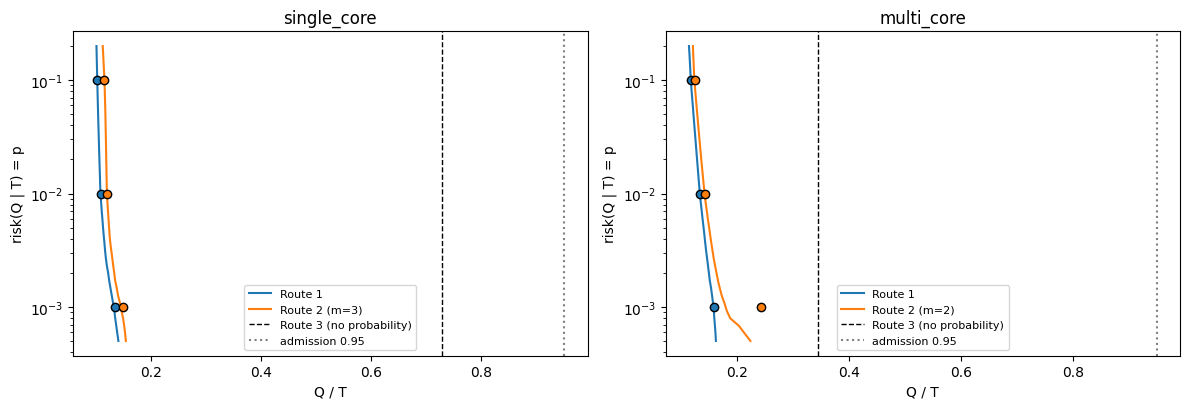

In [18]:
def q_point(scen, conds, p):
    return max(np.quantile(s1_series[(scen, c, i)], 1 - p) for c in conds for i in SCENARIOS[scen])

def alpha_drift_at(scen, p):
    a = alpha_drift_p[scen].sort_index()
    return float(np.exp(np.interp(np.log(p), np.log(a.index.values), np.log(a.values))))

def _route_name(scen, route):
    return "Route 1" if route == "Route 1" else f"Route 2 (m={M_USED[scen]})"

_curves = {}
def _curve(scen, route):
    key = (scen, _route_name(scen, route))
    if key not in _curves:
        conds, plat = (STRESS, 1.0) if key[1] == "Route 1" else (BASELINES, ALPHA_PLATFORM[M_USED[scen]])
        pg = np.logspace(-4, np.log10(0.3), 60)
        _curves[key] = (pg, np.array([q_point(scen, conds, p) * plat * alpha_drift_at(scen, p) for p in pg]))
    return _curves[key]

def budget_at(scen, route, p):
    """budget Q (ms) for the tolerance p"""
    pg, q = _curve(scen, route)
    return float(np.exp(np.interp(np.log(p), np.log(pg), np.log(q))))

def risk_at(scen, route, Q_ms):
    """per-job overrun probability P(C > Q) of the budget Q (ms); end values (1e-4, 0.3) outside the curve"""
    pg, q = _curve(scen, route)
    o = np.argsort(q)
    return float(np.exp(np.interp(np.log(Q_ms), np.log(q[o]), np.log(pg[o]))))

fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(6 * len(SCENARIOS), 4.2), squeeze=False)
for ax, s in zip(axes[0], SCENARIOS):
    pg = np.logspace(-3.3, -0.7, 40)
    for route in ("Route 1", "Route 2"):
        name = _route_name(s, route)
        conds, plat = (STRESS, 1.0) if route == "Route 1" else (BASELINES, ALPHA_PLATFORM[M_USED[s]])
        q = np.array([q_point(s, conds, p) * plat * alpha_drift_at(s, p) for p in pg])
        line, = ax.semilogy(q / T_MS, pg, label=name)
        m = dep[(dep.scenario == s) & (dep.route == name)]
        ax.plot(m.Q_over_T, m.p, "o", color=line.get_color(), mec="k", ms=6)
    h = dep[(dep.scenario == s) & (dep.route == "Route 3")]
    ax.axvline(h.Q_over_T.iloc[0], color="k", ls="--", lw=1, label="Route 3 (no probability)")
    ax.axvline(ADMISSION_MAX, color="grey", ls=":", label=f"admission {ADMISSION_MAX}")
    ax.set(title=s, xlabel="Q / T", ylabel="risk(Q | T) = p"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

Budgets for other tolerances (point estimates, `Q in ms (Q/T)`):

In [19]:
P_TABLE = (0.1, 0.03, 0.01, 0.003, 0.001, 0.0003, 0.0001)
display(pd.DataFrame({(s, _route_name(s, r)): {f"p={p:g}": f"{budget_at(s, r, p):.1f} ({budget_at(s, r, p) / T_MS:.2f})" for p in P_TABLE}
                      for s in SCENARIOS for r in ("Route 1", "Route 2")}).T)

p=0.1      p=0.03      p=0.01     p=0.003     p=0.001    p=0.0003    p=0.0001
single_core Route 1        1.0 (0.10)  1.1 (0.11)  1.1 (0.11)  1.2 (0.12)  1.3 (0.13)  1.6 (0.16)  2.6 (0.26)
            Route 2 (m=3)  1.2 (0.12)  1.2 (0.12)  1.2 (0.12)  1.3 (0.13)  1.5 (0.15)  1.7 (0.17)  2.4 (0.24)
multi_core  Route 1        1.2 (0.12)  1.3 (0.13)  1.3 (0.13)  1.5 (0.15)  1.6 (0.16)  1.7 (0.17)  1.8 (0.18)
            Route 2 (m=2)  1.2 (0.12)  1.3 (0.13)  1.4 (0.14)  1.6 (0.16)  1.8 (0.18)  2.6 (0.26)  3.2 (0.32)

### 5.3 Check on the test VM: budgets against the measured stressed bound
The budgets (profiling-session inputs only) are compared with the stressed bound **measured on the test VM** (4.1), at the p in `TEST_P`.
**Pass rule, fixed before looking:** (1) Q ≥ the measured stressed bound, and (2) the cluster-aware exceedance test of Q on the stressed test-VM run passes. `b/m` = budget / measured bound (min over instances; ≥ 1 covers it). The conservative m is shown as the second Route 2 row.

In [20]:
mrg = bt_all.merge(meas.reset_index()[["scenario", "instance_id", "p", "meas_ucb"]], on=["scenario", "instance_id", "p"])
mrg["b/m"] = mrg.Q_ms / mrg.meas_ucb
mrg["Q >= measured"] = mrg.Q_ms >= mrg.meas_ucb
rows = []
for r in mrg[mrg.p.isin(TEST_P)].itertuples():
    k, kc, exp_cl, pv = exceed_test(run_series[(stress_run[r.scenario], r.scenario, r.instance_id)], r.Q_ms, r.p)
    rows.append(dict(scenario=r.scenario, route=r.route, p=r.p, passed=pv > 0.05))
exc = pd.DataFrame(rows)
t = mrg[mrg.p.isin(TEST_P)]
verdict = t.groupby(["scenario", "route"])["Q >= measured"].all().to_frame().join(exc.groupby(["scenario", "route"]).passed.all().rename("exceedance test"))
verdict["pass"] = verdict.all(axis=1)
for p in TEST_P:
    verdict[f"b/m p={p:g}"] = t[t.p == p].groupby(["scenario", "route"])["b/m"].min()
display(verdict.round(3))

Q >= measured  exceedance test  pass  b/m p=0.01  b/m p=0.001
scenario    route                                                                       
multi_core  Route 1                 True             True  True       1.113        1.159
            Route 2 (m=2)           True             True  True       1.174        1.760
            Route 2 (m=3)           True             True  True       1.229        1.843
            Route 3                 True             True  True       2.404        2.126
single_core Route 1                 True             True  True       1.039        1.050
            Route 2 (m=3)           True             True  True       1.148        1.166
            Route 3                 True             True  True       6.929        5.675

## 6. p_floor: stalls and late jobs that no budget removes

With a generous budget a job can still be skipped or late (VM stalls, late starts). p_floor is that rate. It is a property of the platform, not of the budget: p bounds P(C > Q) only, so the application sees roughly p + p_floor deadline misses.
A job is *bad* if it was skipped or late (R > T). An *event* is a maximal run of consecutive bad jobs (one stall that skips 56 jobs counts once); events are merged across the instances of a run. The **bad-job rate** is the per-job deadline-miss floor; the **event rate** has a one-sided 95% Clopper–Pearson bound.
**Reading the table:** `bad-job rate` is the deadline-miss rate that comes on top of the overruns allowed by p; `longest event` is the longest stall in jobs.

In [21]:
pf_runs = [("S1", s, c, S1 / s / c) for s in SCENARIOS for c in CONDITIONS]
pf_runs += [("S2", s, f"baseline@{vm}", S2 / vm / s / "baseline") for vm in DRIFT_VMS for s in SCENARIOS
            if vm not in EXCLUDE_VMS and (S2 / vm / s / "baseline" / "instance0.csv").exists()]
pf, bad_by = [], {}
for sess, s, c, dr in pf_runs:
    for i in SCENARIOS[s]:
        t_ns = json.load(open(dr / f"{i}.meta.json"))["args"]["period_ms"] * 1e6
        df = pd.read_csv(dr / f"{i}.csv", usecols=["job_id", "response_ns", "skipped", "warmup"]).sort_values("job_id")
        df = df[df.warmup == 0]
        bad = (df.skipped == 1).to_numpy() | ((df.skipped == 0) & (df.response_ns > t_ns)).to_numpy()
        first = bad & ~np.concatenate(([False], bad[:-1]))
        longest = int(np.bincount(np.cumsum(first)[bad]).max()) if bad.any() else 0
        bad_by.setdefault((sess, s, c), []).append(bad)
        pf.append(dict(session=sess, jobs=len(df), bad_jobs=int(bad.sum()), events=int(first.sum()), longest=longest))
pf = pd.DataFrame(pf)

def merged_events(session):
    tot = 0
    for (sess, s, c), arrs in bad_by.items():
        if sess == session:
            u = np.logical_or.reduce(arrs)
            tot += int((u & ~np.concatenate(([False], u[:-1]))).sum())
    return tot

rows = []
for label, sess in (("all runs", None), ("S1 (profiling)", "S1"), ("S2 (other VMs)", "S2")):
    g = pf if sess is None else pf[pf.session == sess]
    n, k = int(g.jobs.sum()), (merged_events("S1") + merged_events("S2") if sess is None else merged_events(sess))
    rows.append({"runs": label, "jobs": n, "events": k, "event rate": f"{k / n:.1e}", "95% upper": f"{cp_upper(k, n):.1e}",
                 "bad-job rate": f"{g.bad_jobs.sum() / n:.1e}", "longest event (jobs)": int(g.longest.max())})
pfloor = pd.DataFrame(rows).set_index("runs")
pfloor_events, pfloor_jobs = merged_events("S1") + merged_events("S2"), int(pf.jobs.sum())
display(pfloor)

,jobs,events,event rate,95% upper,bad-job rate,longest event (jobs)
runs,,,,,,
all runs,1500000,44,2.9e-05,3.8e-05,1.2e-04,5
S1 (profiling),1200000,42,3.5e-05,4.5e-05,1.4e-04,5
S2 (other VMs),300000,2,6.7e-06,2.1e-05,4.0e-05,4


## 7. Offline replay of the budgets

### 7.1 Held-out baselines
Each budget Q* is replayed on the held-out runs (the session-2 baselines of other VMs) with counting the overruns C > Q. Per scenario, route and p, the worst case over runs and instances:
`overrun_over_p` ≤ 1 means the budget meets p; `max_consec` is the longest run of consecutive overruns; `mk_worst_k<k>` the minimum number of jobs within the budget in any window of k jobs; `over_budget_pct` = mean of Q*/Q_oracle − 1, with Q_oracle the (1−p) quantile of the held-out trace (the smallest budget that meets p there).

In [22]:
held = bnd[bnd.session == "s2"][["run", "scenario"]].drop_duplicates()
off = []
for run, s in held.itertuples(index=False):
    for i in SCENARIOS[s]:
        x = run_series[(run, s, i)]
        for r in dep[dep.scenario == s].itertuples():
            off.append(dict(heldout=run, scenario=s, route=r.route, p=r.p, in_use=r.in_use, over_budget=r.Q_ms / np.quantile(x, 1 - r.p) - 1, **replay(x, r.Q_ms, r.p)))
off = pd.DataFrame(off)
o = off[off.in_use & off.p.isin(TEST_P)]
display(o.groupby(["scenario", "route", "p"]).agg(overrun_over_p=("overrun_over_p", "max"), max_consec=("max_consec", "max"),
                                                   over_budget_pct=("over_budget", lambda v: v.mean() * 100),
                                                   **{f"mk_worst_k{k}": (f"mk_worst_k{k}", "min") for k in K_LIST}).round(3))

overrun_over_p  max_consec  over_budget_pct  mk_worst_k10  mk_worst_k100
scenario    route         p                                                                              
multi_core  Route 1       0.001           0.330           2           11.277             8             97
                          0.010           0.534          12            3.774             0             59
            Route 2 (m=2) 0.001           0.100           2           70.329             8             98
                          0.010           0.101           4           10.949             5             91
            Route 3       0.001           0.050           2          140.822             8             98
                          0.010           0.005           2          166.695             8             98
single_core Route 1       0.001           0.070           1           19.154             9             99
                          0.010           0.427           5            2.139             3             89
            Route 2 (m=3) 0.001           0.040           1           32.278             9             99
                          0.010           0.021           2           12.824             8             98
            Route 3       0.001           0.000           0          543.754            10            100
                          0.010           0.000           0          580.984            10            100

Trade-off figure: over-budget (cost) against `overrun rate / p` (calibration of P(C > Q) ≤ p). Left of the dotted line is within the tolerance; the best variant is far left and low.

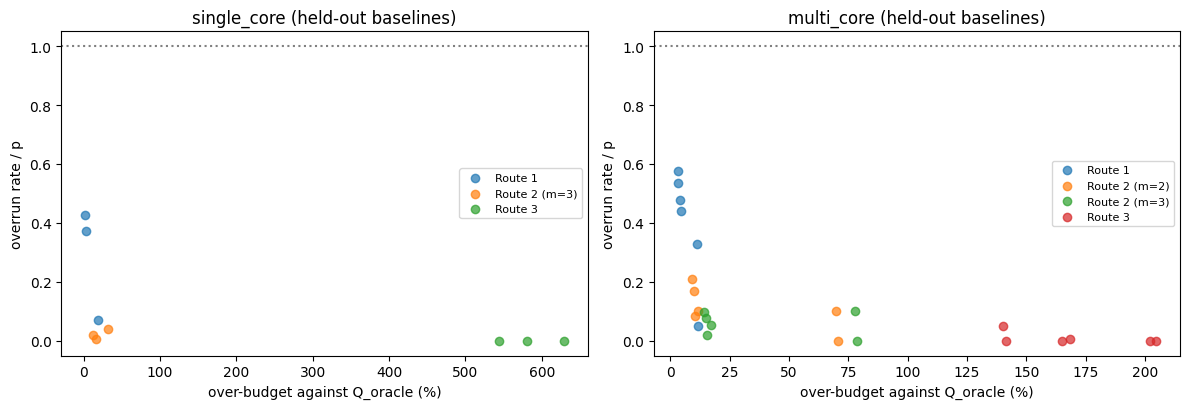

In [23]:
fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(6 * len(SCENARIOS), 4.2), squeeze=False)
for ax, s in zip(axes[0], SCENARIOS):
    for route, g in off[off.scenario == s].groupby("route"):
        ax.scatter(g.over_budget * 100, g.overrun_over_p, label=route, alpha=.7)
    ax.axhline(1, color="grey", ls=":")
    ax.set(title=f"{s} (held-out baselines)", xlabel="over-budget against Q_oracle (%)", ylabel="overrun rate / p"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 7.2 Burst check on the stressed profiling traces
The held-out runs are baselines only; bursts of overruns would show on the stressed traces. They are profiling data, so this checks the **structure** of the misses (consecutive overruns, worst-case (m,k)) at the budgets Q*, not the calibration. Worst case over the stress conditions and instances.

In [24]:
burst = []
for s in SCENARIOS:
    for c in STRESS:
        for i in SCENARIOS[s]:
            for r in dep[(dep.scenario == s) & dep.in_use].itertuples():
                burst.append(dict(scenario=s, condition=c, route=r.route, p=r.p, **replay(s1_series[(s, c, i)], r.Q_ms, r.p)))
burst = pd.DataFrame(burst)
display(burst[burst.p.isin(TEST_P)].groupby(["scenario", "route", "p"]).agg(
    overrun_over_p=("overrun_over_p", "max"), max_consec=("max_consec", "max"), **{f"mk_worst_k{k}": (f"mk_worst_k{k}", "min") for k in K_LIST}).round(3))

overrun_over_p  max_consec  mk_worst_k10  mk_worst_k100
scenario    route         p                                                             
multi_core  Route 1       0.001           0.040           1             9             99
                          0.010           0.008           2             8             98
            Route 2 (m=2) 0.001           0.010           1             9             99
                          0.010           0.006           2             8             98
            Route 3       0.001           0.000           0            10            100
                          0.010           0.000           0            10            100
single_core Route 1       0.001           0.360           2             8             97
                          0.010           0.464          12             0             80
            Route 2 (m=3) 0.001           0.270           2             8             98
                          0.010           0.114           3             5             94
            Route 3       0.001           0.000           0            10            100
                          0.010           0.000           0            10            100

## 8. Online validation under KubeDeadline

### 8.1 Run matrix
The budgets are given to KubeDeadline as the reservation (`runtime` in µs, rounded **up** so the reservation is never below Q*, for `period` = T) and the task is run with and without the memory enemy, on a VM that did not profile the scenario. The matrix below is what has to be run (Route 3 has one budget for every p). The manifests and `run_validation.sh` of the `validation/` folder are built from it.

In [25]:
mat = []
for r in pd.concat([dep[dep.in_use & (dep.route != "Route 3")], dep[(dep.route == "Route 3") & (dep.p == dep.p.max())].assign(p="all")]).itertuples():
    mat.append(dict(scenario=r.scenario, route=r.route, p=r.p, runtime_us=math.ceil(r.Q_ms * 1000), period_us=round(T_MS * 1000), Q_over_T=round(r.Q_over_T, 3), admitted=r.admitted))
mat = pd.DataFrame(mat)
display(mat.set_index(["scenario", "route", "p"]))
n_runs = 2 * len(mat)
print(f"{n_runs} runs (each line runs without and with the enemy) x {JOBS_VALIDATION} jobs = about {n_runs * JOBS_VALIDATION * T_MS / 3.6e6:.1f} h in total")

runtime_us  period_us  Q_over_T  admitted
scenario    route         p                                               
multi_core  Route 1       0.001        1593      10000     0.159      True
                          0.010        1341      10000     0.134      True
                          0.100        1178      10000     0.118      True
            Route 2 (m=2) 0.001        2438      10000     0.244      True
                          0.010        1434      10000     0.143      True
                          0.100        1243      10000     0.124      True
single_core Route 1       0.001        1348      10000     0.135      True
                          0.010        1092      10000     0.109      True
                          0.100        1032      10000     0.103      True
            Route 2 (m=3) 0.001        1496      10000     0.150      True
                          0.010        1207      10000     0.121      True
                          0.100        1161      10000     0.116      True
multi_core  Route 3        all         3446      10000     0.345      True
single_core Route 3        all         7281      10000     0.728      True

28 runs (each line runs without and with the enemy) x 50000 jobs = about 3.9 h in total


### 8.2 Online validation table
Results are read from `validation/results/<scenario>/<route>/<p tag>_<interference>/` (folders on disk: `route1`, `route2b` = Route 2, `hwm` = Route 3; only runs marked `.done`).
B* is the budget of the procedure, the reserved runtime of the run. The budget is valid when the execution time stays within it with probability at least 1 − p, i.e. P(C > B*) ≤ p. One row per scenario, route and p, one column group per interference condition:

- `P(C ≤ B*)`: share of the executed jobs whose CPU time is within B* (worst instance). Valid when ≥ 1 − p.
- `over-budget %`: B* / B_oracle − 1, with B_oracle the (1 − p) quantile of C in that same run, the smallest budget that would have met p there (largest over the instances, which share one reservation). Negative: the run needed more than B*.
- `deadline miss (R > T)`: share of the jobs with response time above T, or skipped (worst instance). Reported, not judged: it also contains the misses that are not caused by an overrun.

Warm-up jobs are left out. Route 3 has one budget for every p, so its run is shown at every p.

In [26]:
def route_label(s, route):
    return {"route1": "Route 1", "route3": "Route 3"}.get(route, _route_name(s, "Route 2"))

def online_run(dr, scen, p):
    """P(C <= B*) and deadline-miss rate (worst instance), over-budget against the run's own (1-p) quantile"""
    txt = (dr / "manifest.yaml").read_text()
    b_us, t_us = (int(re.search(rf"{k}: (\d+)", txt).group(1)) for k in ("runtime", "period"))
    within, missed, oracle = [], [], []
    for i in SCENARIOS[scen]:
        df = pd.read_csv(dr / f"{i}.csv", usecols=["cpu_ns", "response_ns", "skipped", "warmup"])
        df = df[df.warmup == 0]
        c = df.cpu_ns[df.skipped == 0].dropna().to_numpy(dtype=float) / 1e3                # us, executed jobs
        within.append((c <= b_us).mean())
        missed.append(((df.skipped == 1) | (df.response_ns > t_us * 1e3)).mean())
        oracle.append(np.quantile(c, 1 - p))
    return {"P(C>B*)": 1-min(within), "Passed": "PASS" if round(1-min(within), 3) <= p else "FAIL", "over-budget %": 100 * (b_us / max(oracle) - 1), "deadline miss (R > T)": max(missed)}

rows = []
for s in SCENARIOS:
    for route in VAL_ROUTES:
        for tag, p in VAL_P.items():
            for cond in ("none", "memory"):
                dr = VAL / s / VAL_DIRS[route] / (f"all_{cond}" if route == "route3" else f"{tag}_{cond}")
                if (dr / ".done").exists():
                    rows.append(dict(scenario=s, route=route_label(s, route), p=p, interference=cond, **online_run(dr, s, p)))
assert rows, f"no collected validation runs in {VAL.resolve()}"
METRICS = {"P(C>B*)": "{:.4f}", "Passed": "{}", "over-budget %": "{:.1f}", "deadline miss (R > T)": "{:.3f}"}
val = pd.DataFrame(rows).pivot_table(index=["scenario", "route", "p"], columns="interference", aggfunc="first").swaplevel(axis=1)
conds = [c for c in ("none", "memory") if c in val.columns.get_level_values(0)]
val = val.reindex(columns=pd.MultiIndex.from_product([conds, list(METRICS)])).sort_index(ascending=[True, True, False])
styled = val.style.format({c: METRICS[c[1]] for c in val.columns}).format_index("{:g}", axis=0, level="p")
display(styled)

# ---- the same table as LaTeX (booktabs) and HTML, next to the notebook ----
_name = f"online_validation_{RQ2.resolve().name}"
_tex = (val.style.format({c: METRICS[c[1]] for c in val.columns}, escape="latex")
           .format_index("{:g}", axis=0, level="p").format_index(escape="latex", axis=0, level=["scenario", "route"]).format_index(escape="latex", axis=1)
           .to_latex(hrules=True, multicol_align="c", clines="skip-last;data"))
Path(f"{_name}.tex").write_text(_tex)
Path(f"{_name}.html").write_text("<!doctype html><meta charset='utf-8'><title>Online validation</title>" + styled.to_html())
print(f"saved {_name}.tex and {_name}.html")

saved online_validation_workload3.tex and online_validation_workload3.html


In [27]:
styled = (val.style
        .format({c: METRICS[c[1]] for c in val.columns})
        .format_index("{:g}", axis=0, level="p"))

# ---- HTML ----
html = "<!doctype html><meta charset='utf-8'><title>Online validation</title>" + styled.to_html()
Path("online_validation.html").write_text(html)

# ---- LaTeX (needs \usepackage{booktabs} and \usepackage{multirow}) ----
latex = (val.style
        .format({c: METRICS[c[1]] for c in val.columns}, escape="latex")
        .format_index("{:g}", axis=0, level="p")
        .format_index(escape="latex", axis=0, level=["scenario", "route"])
        .format_index(escape="latex", axis=1)
        .to_latex(hrules=True, multicol_align="c", clines="skip-last;data"))
Path("online_validation.tex").write_text(latex)
print(latex)

\begin{tabular}{lllrlrrrlrr}
\toprule
 &  &  & \multicolumn{4}{c}{none} & \multicolumn{4}{c}{memory} \\
 &  &  & P(C>B*) & Passed & over-budget \% & deadline miss (R > T) & P(C>B*) & Passed & over-budget \% & deadline miss (R > T) \\
scenario & route & p &  &  &  &  &  &  &  &  \\
\midrule
\multirow[c]{9}{*}{multi\_core} & \multirow[c]{3}{*}{Route 1} & 0.1 & 0.0434 & PASS & 10.9 & 0.201 & 0.0040 & PASS & 15.8 & 0.011 \\
 &  & 0.01 & 0.0079 & PASS & 5.9 & 0.017 & 0.0004 & PASS & 26.4 & 0.001 \\
 &  & 0.001 & 0.0010 & PASS & -0.7 & 0.003 & 0.0024 & FAIL & -30.8 & 0.006 \\
\cline{2-11}
 & \multirow[c]{3}{*}{Route 2 (m=2)} & 0.1 & 0.0487 & PASS & 14.7 & 0.101 & 0.0040 & PASS & 19.1 & 0.011 \\
 &  & 0.01 & 0.0002 & PASS & 37.8 & 0.001 & 0.0008 & PASS & 26.0 & 0.002 \\
 &  & 0.001 & 0.0003 & PASS & 53.5 & 0.001 & 0.0010 & PASS & -0.2 & 0.003 \\
\cline{2-11}
 & \multirow[c]{3}{*}{Route 3} & 0.1 & 0.0000 & PASS & 263.9 & 0.000 & 0.0000 & PASS & 239.1 & 0.000 \\
 &  & 0.01 & 0.0000 & PASS & 245

## 9. Assumption check: server alignment in HCBS

With a hard reservation whose period is T, an overrun (C > Q) is sufficient for a deadline miss, not necessary: a job with C ≤ Q can still miss. The tolerance p bounds only the overruns, so the budget verdict does not rely on C ≤ Q ⇒ R ≤ D; the misses not explained by overruns show in the `deadline miss` column of the online validation. One source of such misses is the replenishment: if the budget is refilled by a free-running periodic timer instead of aligned with the job releases (the CBS wake-up rule), a job with C ≤ Q can be split across two server periods and finish late.
**To check** in the KubeDeadline/HCBS code or documentation: when the replenishment instant is set (on wake-up, or at a fixed period boundary), and what happens to the remaining budget when a job arrives in the middle of a server period. The `deadline miss` column of section 8.2 is the empirical side of this check. Status: the code is not in this repository, so the source check is open.